# 01 · Exploration de Roboflow « garbage classification by yolo » (détection)

Objectif : connaître le dataset avant d'entraîner YOLO.
Questions : combien d'images et de déchets par split ? quelles classes ? quelle taille de boxes ? combien de copies augmentées, et le test est-il « propre » ?

In [1]:
# Cellule 1 : imports et chemins
from pathlib import Path
import random

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image

ROOT = Path.cwd()
while not (ROOT / "ml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA = ROOT / "ml" / "data" / "raw" / "roboflow"
FIG = ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

print("Projet  :", ROOT)
print("Données :", DATA, "->", "OK" if DATA.exists() else "INTROUVABLE")
print("Contenu :", sorted(p.name for p in DATA.iterdir()))

Projet  : c:\trashProject
Données : c:\trashProject\ml\data\raw\roboflow -> OK
Contenu : ['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'test', 'train', 'valid']


In [2]:
# Cellule 2 : data.yaml -> noms des classes (l'ordre donne le sens des numéros 0, 1, 2, 3)
config = yaml.safe_load((DATA / "data.yaml").read_text(encoding="utf-8"))
NAMES = config["names"]
if isinstance(NAMES, dict):
    NAMES = [NAMES[k] for k in sorted(NAMES)]
print("nc    :", config.get("nc"))
print("names :", {i: n for i, n in enumerate(NAMES)})

nc    : 4
names : {0: 'glass', 1: 'metal', 2: 'paper', 3: 'plastic'}


In [3]:
# Cellule 3 : images et fichiers de labels par split
SPLITS = [s for s in ["train", "valid", "test"] if (DATA / s).exists()]
EXTS = {".jpg", ".jpeg", ".png"}

images = []
for s in SPLITS:
    for f in sorted((DATA / s / "images").iterdir()):
        if f.suffix.lower() in EXTS:
            label = DATA / s / "labels" / (f.stem + ".txt")
            images.append({"split": s, "image": f, "label": label, "a_un_label": label.exists(),
                           # le nom de la photo d'origine = tout ce qui est avant ".rf."
                           "origine": f.stem.split(".rf.")[0]})
imgs = pd.DataFrame(images)
display(imgs.groupby("split").agg(images=("image", "size"), sans_label=("a_un_label", lambda x: (~x).sum())))

,images,sans_label
split,,
test,120,0
train,2517,0
valid,240,0


In [4]:
# Cellule 4 : lecture de toutes les boxes (une ligne par déchet)
def lire_label(path):
    boxes = []
    if not path.exists():
        return boxes
    for ligne in path.read_text().split("\n"):
        v = ligne.split()
        if len(v) < 5:
            continue
        c, nums = int(v[0]), [float(x) for x in v[1:]]
        if len(nums) == 4:                       # format box : x_centre y_centre largeur hauteur
            x, y, w, h = nums
        else:                                    # format polygone : x1 y1 x2 y2 ... -> on prend le rectangle englobant
            xs, ys = nums[0::2], nums[1::2]
            x, y = (min(xs) + max(xs)) / 2, (min(ys) + max(ys)) / 2
            w, h = max(xs) - min(xs), max(ys) - min(ys)
        boxes.append({"classe": NAMES[c], "x": x, "y": y, "w": w, "h": h, "polygone": len(nums) > 4})
    return boxes

rows = []
for r in imgs.itertuples():
    for b in lire_label(r.label):
        rows.append({"split": r.split, "image": r.image.name, "origine": r.origine, **b})
boxes = pd.DataFrame(rows)
print(f"{len(boxes)} déchets annotés dans {len(imgs)} images")
print("Lignes au format polygone :", int(boxes["polygone"].sum()))

4023 déchets annotés dans 2877 images
Lignes au format polygone : 15


split,train,valid,test,total
classe,,,,
glass,978,79,43,1100
metal,909,86,45,1040
paper,765,71,35,871
plastic,903,74,35,1012


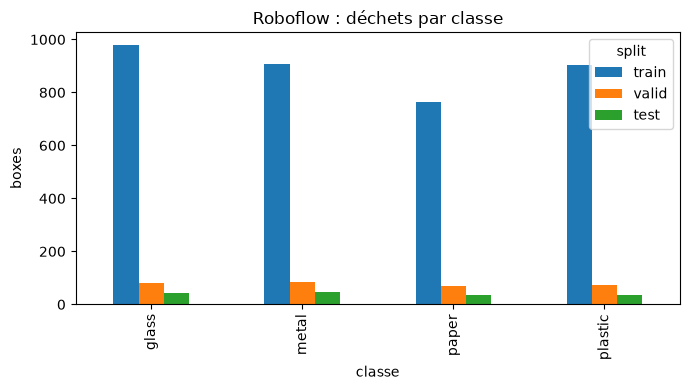

In [5]:
# Cellule 5 : déchets par classe et par split -> déséquilibre ?
table = boxes.pivot_table(index="classe", columns="split", values="x", aggfunc="count", fill_value=0)
table = table[[s for s in SPLITS if s in table.columns]]
table["total"] = table.sum(axis=1)
display(table)

table.drop(columns="total").plot.bar(figsize=(7, 4), title="Roboflow : déchets par classe")
plt.ylabel("boxes")
plt.tight_layout()
plt.savefig(FIG / "roboflow_classes.png", dpi=100)
plt.show()

Images sans aucun déchet : {}


,mean,min,50%,max
split,,,,
test,1.3,1.0,1.0,10.0
train,1.4,1.0,1.0,20.0
valid,1.3,1.0,1.0,9.0


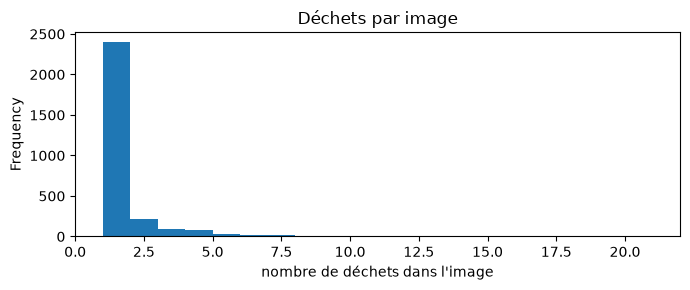

In [6]:
# Cellule 6 : nombre de déchets par image
par_image = boxes.groupby(["split", "image"]).size()
vides = imgs.loc[~imgs["image"].map(lambda p: p.name).isin(boxes["image"]), "split"].value_counts()
print("Images sans aucun déchet :", vides.to_dict())
display(par_image.groupby("split").describe()[["mean", "min", "50%", "max"]].round(1))

par_image.plot.hist(bins=range(1, int(par_image.max()) + 2), figsize=(7, 3), title="Déchets par image")
plt.xlabel("nombre de déchets dans l'image")
plt.tight_layout()
plt.show()

Taille des images : 640 x 640


,mean,min,50%,max
classe,,,,
glass,32.8,2.5,28.5,100.0
metal,35.8,1.2,32.8,99.4
paper,51.7,2.7,56.6,98.0
plastic,32.9,0.4,31.5,85.7


Boxes de moins de 32 pixels de côté : 0.1 %


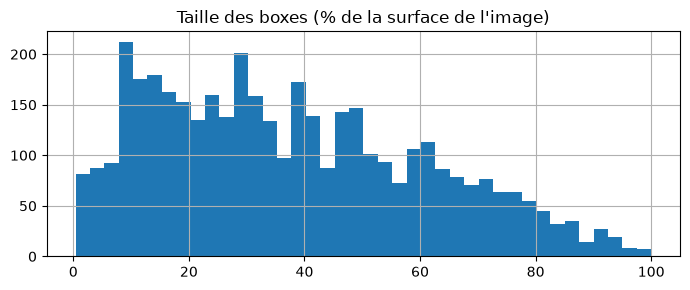

In [7]:
# Cellule 7 : taille des boxes (en % de l'image) et petits objets
w0, h0 = Image.open(imgs["image"].iloc[0]).size
boxes["aire_%"] = boxes["w"] * boxes["h"] * 100
boxes["petit"] = (boxes["w"] * w0 < 32) | (boxes["h"] * h0 < 32)
print(f"Taille des images : {w0} x {h0}")
display(boxes.groupby("classe")["aire_%"].describe()[["mean", "min", "50%", "max"]].round(1))
print(f"Boxes de moins de 32 pixels de côté : {boxes['petit'].mean() * 100:.1f} %")

boxes["aire_%"].hist(bins=40, figsize=(7, 3))
plt.title("Taille des boxes (% de la surface de l'image)")
plt.tight_layout()
plt.savefig(FIG / "roboflow_tailles_boxes.png", dpi=100)
plt.show()

In [8]:
# Cellule 8 : copies augmentées et fuite entre splits
copies = imgs.groupby(["split", "origine"]).size()
display(copies.groupby("split").describe()[["count", "mean", "max"]]
        .rename(columns={"count": "photos d'origine", "mean": "copies par photo", "max": "max copies"}).round(2))

splits_par_origine = imgs.groupby("origine")["split"].nunique()
fuites = splits_par_origine[splits_par_origine > 1]
print(f"Photos d'origine présentes dans plusieurs splits : {len(fuites)}")
display(imgs[imgs["origine"].isin(fuites.index)].sort_values("origine")[["origine", "split"]].head(20))

,photos d'origine,copies par photo,max copies
split,,,
test,120.0,1.0,1.0
train,839.0,3.0,3.0
valid,240.0,1.0,1.0


Photos d'origine présentes dans plusieurs splits : 0


,origine,split


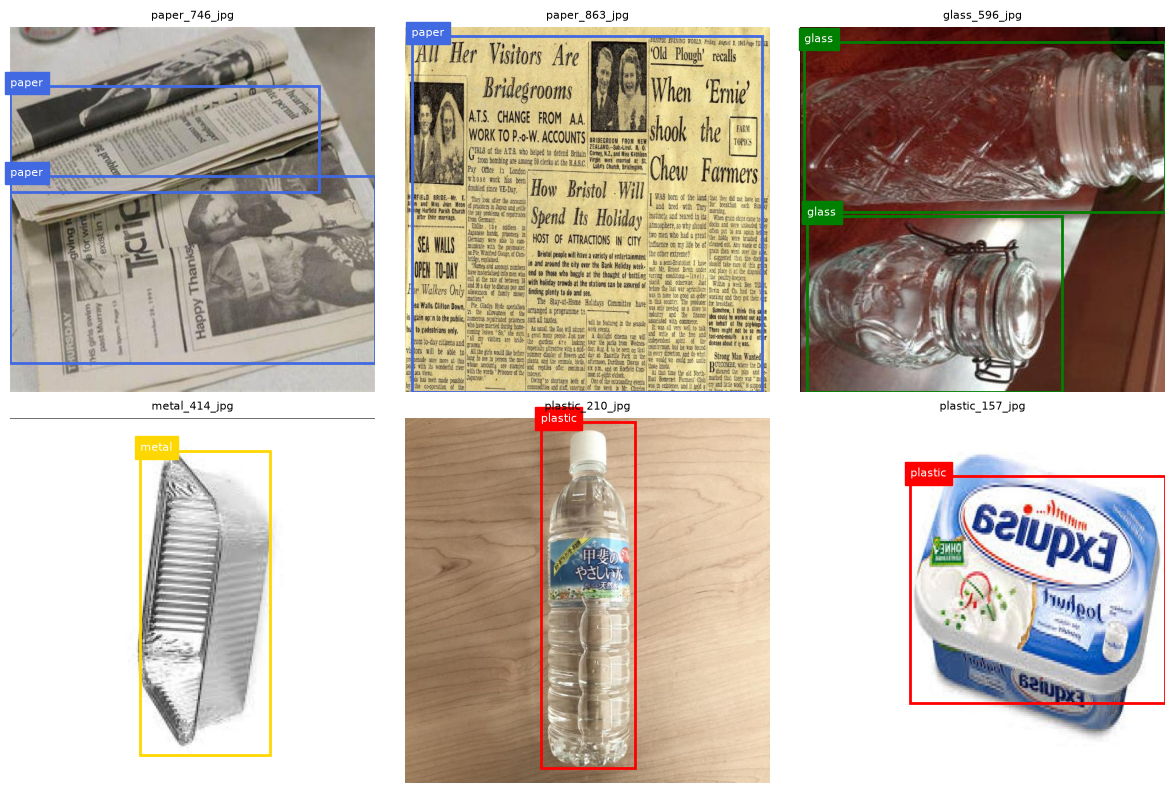

In [9]:
# Cellule 9 : 6 images au hasard avec leurs boxes
COULEURS = {"glass": "green", "metal": "gold", "paper": "royalblue", "plastic": "red"}
random.seed(0)
choix = random.sample(list(imgs[imgs["split"] == "train"].itertuples()), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, r in zip(axes.ravel(), choix):
    im = Image.open(r.image)
    ax.imshow(im)
    for b in lire_label(r.label):
        x0, y0 = (b["x"] - b["w"] / 2) * im.width, (b["y"] - b["h"] / 2) * im.height
        ax.add_patch(patches.Rectangle((x0, y0), b["w"] * im.width, b["h"] * im.height,
                                       fill=False, color=COULEURS.get(b["classe"], "white"), linewidth=2))
        ax.text(x0, y0, b["classe"], color="white", fontsize=8,
                backgroundcolor=COULEURS.get(b["classe"], "black"))
    ax.set_title(r.origine[:30], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG / "roboflow_exemples.png", dpi=80)
plt.show()

In [10]:
# Cellule 10 : résumé à recopier dans docs/eda-roboflow.md
print("Classes             :", NAMES)
print("Images par split    :", imgs["split"].value_counts().to_dict())
print("Photos d'origine    :", imgs["origine"].nunique())
print("Déchets par classe  :", boxes["classe"].value_counts().to_dict())
print("Déchets par image   :", round(par_image.mean(), 1), "en moyenne, max", int(par_image.max()))
print("Petites boxes       :", f"{boxes['petit'].mean() * 100:.1f} %")
print("Fuites entre splits :", len(fuites))

Classes             : ['glass', 'metal', 'paper', 'plastic']
Images par split    : {'train': 2517, 'valid': 240, 'test': 120}
Photos d'origine    : 1199
Déchets par classe  : {'glass': 1100, 'metal': 1040, 'plastic': 1012, 'paper': 871}
Déchets par image   : 1.4 en moyenne, max 20
Petites boxes       : 0.1 %
Fuites entre splits : 0
